In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import bayesflow as bf

import sys
sys.path.append("../")

from src.generative_models import *
from src.priors import *

np.set_printoptions(suppress=True)

In [67]:
data = pd.read_csv("../data/pilot_2_data_prepped_excluded.csv")
NUM_SUBJECTS = len(data.id.unique())
SUBJECTS = data.id.unique()
NUM_OBS = 84
NUM_SAMPLES = 1000

In [114]:
import matplotlib
matplotlib.rcParams['font.serif'] = "Palatino"
matplotlib.rcParams['font.family'] = "serif"

FONTSIZE_1 = 24
FONTSIZE_2 = 16

In [69]:
emp_data = np.zeros((NUM_SUBJECTS, 2, NUM_OBS, 7))
for i, subject in enumerate(SUBJECTS):
    subject_data_old = data[(data.id == subject) & (data.condition == "old")]
    subject_data_new = data[(data.id == subject) & (data.condition == "new")]
    
    resp_old = subject_data_old.resp.to_numpy()[:, None]
    resp_new = subject_data_new.resp.to_numpy()[:, None]

    context_old = subject_data_old.iloc[:, 8:14].to_numpy() / 50
    context_new = subject_data_new.iloc[:, 8:14].to_numpy() / 50
    emp_data[i, 0] = np.c_[resp_old, context_old]
    emp_data[i, 1] = np.c_[resp_new, context_new]

## Model Fitting

### PT

In [70]:
summary_net = bf.networks.SetTransformer(input_dim=7, summary_dim=32)

inference_net = bf.networks.InvertibleNetwork(
    num_params=len(pt_prior.param_names),
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False},
)

In [71]:
pt_amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net)

pt_trainer = bf.trainers.Trainer(
    generative_model=pt_model, 
    amortizer=pt_amortizer, 
    configurator=pt_configurator, 
    checkpoint_path=f"../checkpoints/new_approach/{pt_model.name}",
    max_to_keep=1
)

INFO:root:Loaded loss history from ../checkpoints/new_approach/pt_model/history_100.pkl.
INFO:root:Networks loaded from ../checkpoints/new_approach/pt_model/ckpt-100
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [72]:
pt_post_z = np.zeros((NUM_SUBJECTS, 2, NUM_SAMPLES, 3))

In [73]:
pt_post_z[:, 0] = pt_amortizer.sample(
    {"summary_conditions": emp_data[:, 0].astype(np.float32)},
    NUM_SAMPLES
)
pt_post_z[:, 1] = pt_amortizer.sample(
    {"summary_conditions": emp_data[:, 1].astype(np.float32)},
    NUM_SAMPLES
)

In [74]:
pt_post = pt_post_z * PT_PRIOR_STD + PT_PRIOR_MEAN

In [122]:
pt_post.shape

(24, 2, 1000, 3)

In [ ]:
pt_post_median = np.median(pt_post, axis=2)

array([[1.6708648 , 0.83475692, 0.80751264],
       [1.52537368, 0.78261038, 0.54695014]])

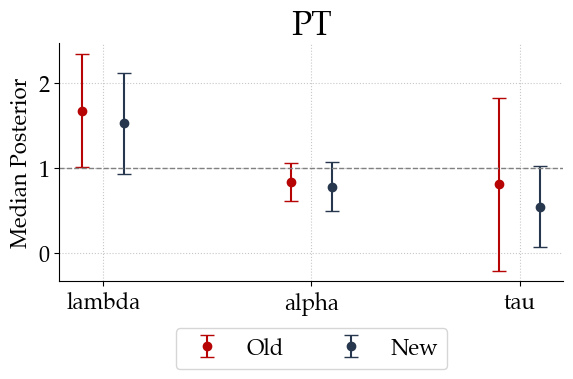

In [121]:
param_names = ['lambda', 'alpha', 'tau']
n_subjects, n_conditions, n_samples, n_params = pt_post.shape
colors = ['#B70404', '#27374D']  # Old, New
condition_labels = ['Old', 'New']

# Compute subject-wise medians, then group mean and std
subject_medians = np.median(pt_post, axis=2)  # shape: (12, 2, 3)
mean_medians = subject_medians.mean(axis=0)   # shape: (2, 3)
std_medians = subject_medians.std(axis=0)     # shape: (2, 3)

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(n_params)
width = 0.2  # dodge

for c in range(n_conditions):
    x_offset = x - width/2 + c*width
    y = mean_medians[c]
    yerr = std_medians[c]
    ax.errorbar(x_offset, y, yerr=yerr, fmt='o', color=colors[c], capsize=5,
                label=condition_labels[c], markersize=6)

# Reference line at y=1
ax.axhline(1, color='gray', linestyle='--', linewidth=1)

# Grid
ax.grid(True, which='both', linestyle=':', linewidth=0.8, alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(param_names)
ax.legend()
ax.set_xticklabels(param_names, fontsize=FONTSIZE_2)
ax.set_ylabel('Median Posterior', fontsize=FONTSIZE_2)
ax.tick_params(axis='y', labelsize=FONTSIZE_2)
ax.tick_params(axis='x', labelsize=FONTSIZE_2)

ax.set_title('PT', fontsize=FONTSIZE_1)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=FONTSIZE_2)
plt.tight_layout()
sns.despine()
plt.savefig(
    "../plots/new_approach/pt_estimates.pdf",
    bbox_inches='tight',
    dpi=600,
    transparent=True
) 

### CPT

In [80]:
summary_net = bf.networks.SetTransformer(input_dim=7, summary_dim=32)

inference_net = bf.networks.InvertibleNetwork(
    num_params=4,
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False},
)

In [81]:
cpt_amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net)

cpt_trainer = bf.trainers.Trainer(
    generative_model=cpt_model, 
    amortizer=cpt_amortizer, 
    configurator=cpt_configurator, 
    checkpoint_path=f"../checkpoints/new_approach/{cpt_model.name}",
    max_to_keep=1
)

INFO:root:Loaded loss history from ../checkpoints/new_approach/cpt_model/history_100.pkl.
INFO:root:Networks loaded from ../checkpoints/new_approach/cpt_model/ckpt-100
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [82]:
cpt_post_z = np.zeros((NUM_SUBJECTS, 2, NUM_SAMPLES, 4))

In [83]:
cpt_post_z[:, 0] = cpt_amortizer.sample(
    {"summary_conditions": emp_data[:, 0].astype(np.float32)},
    NUM_SAMPLES
)
cpt_post_z[:, 1] = cpt_amortizer.sample(
    {"summary_conditions": emp_data[:, 1].astype(np.float32)},
    NUM_SAMPLES
)

In [84]:
cpt_post = cpt_post_z * CPT_PRIOR_STD + CPT_PRIOR_MEAN

In [ ]:
cpt_post_median = np.median(cpt_post, axis=2)

array([[1.61496037, 0.85778495, 0.85795709, 0.77426632],
       [1.29231778, 0.6923369 , 0.8772531 , 0.61623913]])

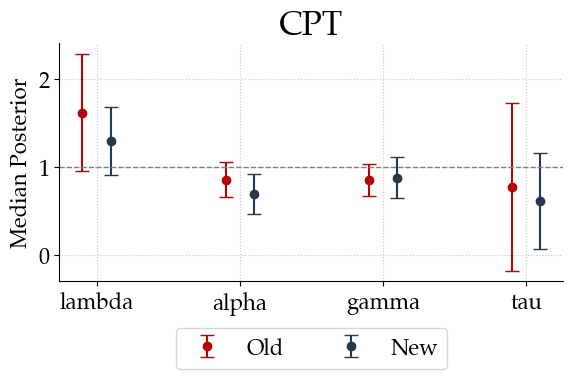

In [117]:
param_names = ['lambda', 'alpha', 'gamma', 'tau']
n_subjects, n_conditions, n_samples, n_params = cpt_post.shape
colors = ['#B70404', '#27374D']  # Old, New
condition_labels = ['Old', 'New']

# Compute subject-wise medians, then group mean and std
subject_medians = np.median(cpt_post, axis=2)  # shape: (12, 2, 3)
mean_medians = subject_medians.mean(axis=0)   # shape: (2, 3)
std_medians = subject_medians.std(axis=0)     # shape: (2, 3)

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(n_params)
width = 0.2  # dodge

for c in range(n_conditions):
    x_offset = x - width/2 + c*width
    y = mean_medians[c]
    yerr = std_medians[c]
    ax.errorbar(x_offset, y, yerr=yerr, fmt='o', color=colors[c], capsize=5,
                label=condition_labels[c], markersize=6)

# Reference line at y=1
ax.axhline(1, color='gray', linestyle='--', linewidth=1)

# Grid
ax.grid(True, which='both', linestyle=':', linewidth=0.8, alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(param_names)
ax.legend()
ax.set_xticklabels(param_names, fontsize=FONTSIZE_2)
ax.set_ylabel('Median Posterior', fontsize=FONTSIZE_2)
ax.tick_params(axis='y', labelsize=FONTSIZE_2)
ax.tick_params(axis='x', labelsize=FONTSIZE_2)

ax.set_title('CPT', fontsize=FONTSIZE_1)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=FONTSIZE_2)
plt.tight_layout()
sns.despine()
plt.savefig(
    "../plots/new_approach/cpt_estimates.pdf",
    bbox_inches='tight',
    dpi=600,
    transparent=True
) 

### MVL

In [88]:
summary_net = bf.networks.SetTransformer(input_dim=7, summary_dim=32)

inference_net = bf.networks.InvertibleNetwork(
    num_params=3,
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False}
)

In [90]:
mvl_amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net)

In [91]:
trainer = bf.trainers.Trainer(
    generative_model=mvl_model, 
    amortizer=mvl_amortizer, 
    configurator=mvl_configurator, 
    checkpoint_path=f"../checkpoints/new_approach/{mvl_model.name}",
    max_to_keep=1
)

INFO:root:Loaded loss history from ../checkpoints/new_approach/mvl_model/history_84.pkl.
INFO:root:Networks loaded from ../checkpoints/new_approach/mvl_model/ckpt-84
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [96]:
mvl_post_z = np.zeros((NUM_SUBJECTS, 2, NUM_SAMPLES, 3))

In [97]:
mvl_post_z[:, 0] = mvl_amortizer.sample(
    {"summary_conditions": emp_data[:, 0].astype(np.float32)},
    NUM_SAMPLES
)
mvl_post_z[:, 1] = mvl_amortizer.sample(
    {"summary_conditions": emp_data[:, 1].astype(np.float32)},
    NUM_SAMPLES
)

In [98]:
mvl_post = mvl_post_z * MVL_PRIOR_STD + MVL_PRIOR_MEAN

In [103]:
mvl_post_median = np.median(mvl_post, axis=2)

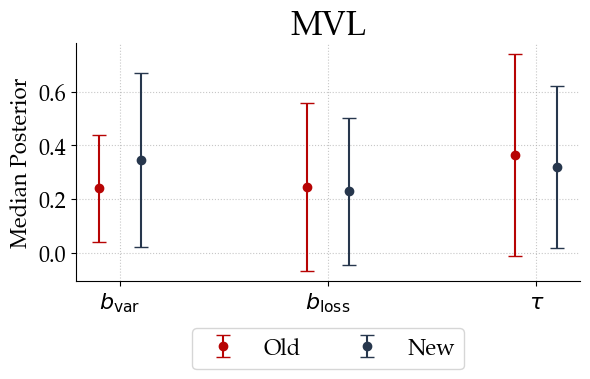

In [118]:
n_subjects, n_conditions, n_samples, n_params = mvl_post.shape
colors = ['#B70404', '#27374D']  # Old, New
condition_labels = ['Old', 'New']

# Compute subject-wise medians, then group mean and std
subject_medians = np.median(mvl_post, axis=2)  # shape: (12, 2, 3)
mean_medians = subject_medians.mean(axis=0)   # shape: (2, 3)
std_medians = subject_medians.std(axis=0)     # shape: (2, 3)

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(n_params)
width = 0.2  # dodge

for c in range(n_conditions):
    x_offset = x - width/2 + c*width
    y = mean_medians[c]
    yerr = std_medians[c]
    ax.errorbar(x_offset, y, yerr=yerr, fmt='o', color=colors[c], capsize=5,
                label=condition_labels[c], markersize=6)

# Reference line at y=1
# ax.axhline(1, color='gray', linestyle='--', linewidth=1)

# Grid
ax.grid(True, which='both', linestyle=':', linewidth=0.8, alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(mvl_param_names)
ax.legend()
ax.set_xticklabels(mvl_param_names, fontsize=FONTSIZE_2)
ax.set_ylabel('Median Posterior', fontsize=FONTSIZE_2)
ax.tick_params(axis='y', labelsize=FONTSIZE_2)
ax.tick_params(axis='x', labelsize=FONTSIZE_2)

ax.set_title('MVL', fontsize=FONTSIZE_1)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=FONTSIZE_2)
plt.tight_layout()
sns.despine()
plt.savefig(
    "../plots/new_approach/mvl_estimates.pdf",
    bbox_inches='tight',
    dpi=600,
    transparent=True
)

## Posterior Re-simulation